# Create SCA time series for model outputs

In [1]:
import os
from glob import glob
import rioxarray as rxr
import xarray as xr
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# inputs
base_dir = "/Users/rdcrlrka/Research/SIRO/MCS_SCA/"

# outputs
out_dir = os.path.join(base_dir, "model_SCA_maps")

# Define a SWE threshold for determining "snow-covered" vs "snow-free"
swe_thresh = 0.10 # m

## Main processing function

In [2]:
def swe_to_sca(files=None, swe_thresh=0.1, out_file=None):
    # Create compiled SCA dataset
    print("Compiling SWE time series, calculating SCA...")
    sca_list = []
    for file in tqdm(files):
        swe = xr.open_dataset(file).squeeze()
        sca = (swe >= swe_thresh)

        # For HMS, parse date from the file name and add the time stamp
        if "HMS" in os.path.basename(out_file):
            date = os.path.basename(file).split("T0000_")[1].replace('_','-')
            dt = np.datetime64(date)
            sca = sca.expand_dims(time=[dt])

        sca_list += [sca]
    sca_compiled = xr.concat(sca_list, dim='time')

    # Convert to integer with nodata value=255
    sca_compiled = xr.where(np.isnan(sca_compiled), 255, sca_compiled).astype(np.uint8)

    # Reduce to a DataArray
    if "HMS" in os.path.basename(out_file):
        sca_compiled_band = sca_compiled.band_data
    elif "SnowModel" in os.path.basename(out_file):
        sca_compiled_band = sca_compiled.SWE

    # Save to file
    sca_compiled_band.to_netcdf(out_file)
    print("Compiled SCA time series saved to:", out_file)

    return sca_compiled_band


## Calculate SCA time series for each model

In [3]:
os.makedirs(out_dir, exist_ok=True)

# --- Locate input files ---
hms_swe_files = sorted(glob(os.path.join(base_dir, "model_SWE", "HMS", "*.tiff")))
sm_swe_files = sorted(glob(os.path.join(base_dir, "model_SWE", "SnowModel", "*.nc")))

# --- Iterate over models ---
results_dict = {}
for swe_files, model_name in zip(
    [hms_swe_files, sm_swe_files],
    ["HMS", "SnowModel"]
    ):
    print(f"\n{model_name}\n----------")

    # Define output file
    sca_file = os.path.join(out_dir, f"{model_name}_SCA_timeseries_SWEthresh{swe_thresh}.nc")

    # Check if it already exists
    if os.path.exists(sca_file):
        print(f"SCA time series already exists for {model_name}, loading.")
        sca_compiled = xr.open_dataset(sca_file)
    else:

        # Create compiled SCA time series from SWE
        sca_compiled = swe_to_sca(
            swe_files, 
            out_file = sca_file
            )

    # Add to results dictionary
    results_dict[model_name] = {
        "SCA_time_series": sca_compiled,
        "spatial_res_m": abs(sca_compiled.x.data[1] - sca_compiled.x.data[0])
    }




HMS
----------
Compiling SWE time series, calculating SCA...


100%|██████████| 223/223 [00:00<00:00, 296.33it/s]


Compiled SCA time series saved to: /Users/rdcrlrka/Research/SIRO/MCS_SCA/model_SCA_maps/HMS_SCA_timeseries_SWEthresh0.1.nc

SnowModel
----------
Compiling SWE time series, calculating SCA...


100%|██████████| 3/3 [00:00<00:00,  7.24it/s]
/var/folders/46/lc6lgy656cq4n776s7js9r880000gr/T/ipykernel_51879/1389646232.py:16: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  sca_compiled = xr.concat(sca_list, dim='time')


Compiled SCA time series saved to: /Users/rdcrlrka/Research/SIRO/MCS_SCA/model_SCA_maps/SnowModel_SCA_timeseries_SWEthresh0.1.nc


## Plot a quick comparison

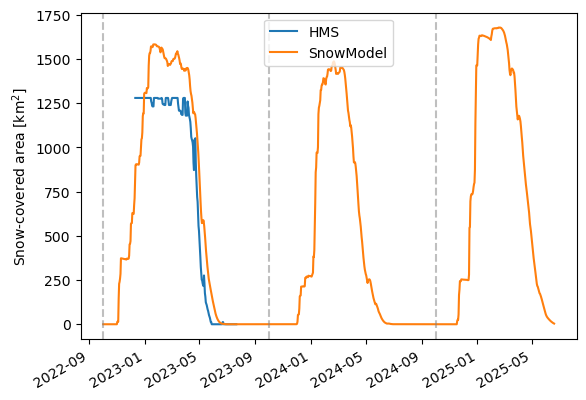

In [4]:
fig, ax = plt.subplots()

for model_name in results_dict.keys():
    sca_total_m2 = results_dict[model_name]["SCA_time_series"] * (results_dict[model_name]["spatial_res_m"]**2)
    sca_total_sum_m2 = sca_total_m2.sum(dim='x').sum(dim='y')
    if type(sca_total_sum_m2)!=xr.DataArray:
        sca_total_sum_m2 = sca_total_sum_m2.to_array().squeeze()
    ax.plot(sca_total_sum_m2.time, sca_total_sum_m2.data / 1e6, '-', label=model_name)

ax.legend()
ax.set_ylabel("Snow-covered area [km$^2$]")
fig.autofmt_xdate()
for year in range(2022, 2025):
    ax.axvline(np.datetime64(f"{year}-10-01"), color='gray', linestyle='--', alpha=0.5)

plt.show()